In [36]:
#get Data
#get data from GitHub -> https://github.com/keuperj/DATA
!git clone https://github.com/keuperj/DATA.git

fatal: destination path 'DATA' already exists and is not an empty directory.


# Ex 1.2: A simple parallel MapReduce framework in Python
Now we use the [*multiprocessing*](https://docs.python.org/3/library/multiprocessing.html) lib to actually do things in parallel

In [37]:
import collections
import itertools
import multiprocessing


class SimpleMapReduce:

    def __init__(self, map_func, reduce_func, num_workers=None):
        """
        map_func

          Function to map inputs to intermediate data. Takes as
          argument one input value and returns a tuple with the
          key and a value to be reduced.

        reduce_func

          Function to reduce partitioned version of intermediate
          data to final output. Takes as argument a key as
          produced by map_func and a sequence of the values
          associated with that key.

        num_workers

          The number of workers to create in the pool. Defaults
          to the number of CPUs available on the current host.
        """
        self.map_func = map_func
        self.reduce_func = reduce_func
        self.pool = multiprocessing.Pool(num_workers)

    def partition(self, mapped_values):
        """Organize the mapped values by their key.
        Returns an unsorted sequence of tuples with a key
        and a sequence of values.
        """
        partitioned_data = collections.defaultdict(list)
        for key, value in mapped_values:
            partitioned_data[key].append(value)
        return partitioned_data.items()

    def __call__(self, inputs, chunksize=1):
        """Process the inputs through the map and reduce functions
        given.

        inputs
          An iterable containing the input data to be processed.

        chunksize=1
          The portion of the input data to hand to each worker.
          This can be used to tune performance during the mapping
          phase.
        """
        map_responses = self.pool.map(
            self.map_func,
            inputs,
            chunksize=chunksize,
        )
        partitioned_data = self.partition(
            itertools.chain(*map_responses)
        )
        reduced_values = self.pool.map(
            self.reduce_func,
            partitioned_data,
        )
        return reduced_values

### A Word Count example

In [38]:
import string

# map - read file and count words
def file_to_words(filename):
    """Read a file and return a sequence of
    (word, occurences) values.
    """
    STOP_WORDS = set([
        'a', 'an', 'and', 'are', 'as', 'be', 'by', 'for', 'if',
        'in', 'is', 'it', 'of', 'or', 'py', 'rst', 'that', 'the',
        'to', 'with',
    ])
    TR = str.maketrans({
        p: ' '
        for p in string.punctuation
    })

    print('{} reading {}'.format(
        multiprocessing.current_process().name, filename))
    output = []

    with open(filename, 'rt') as f:
        for line in f:
            # Skip comment lines.
            if line.lstrip().startswith('..'):
                continue
            line = line.translate(TR)  # Strip punctuation
            for word in line.split():
                word = word.lower()
                if word.isalpha() and word not in STOP_WORDS:
                    output.append((word, 1))
    return output

# reduce
def count_words(item):
    """Convert the partitioned data for a word to a
    tuple containing the word and the number of occurences.
    """
    word, occurences = item
    return (word, sum(occurences))

In [39]:
import operator
import glob #easy file access

input_files = glob.glob('DATA/*.rst')#get all text files names

mapper = SimpleMapReduce(file_to_words, count_words)#get mapreduce instance with custom map and reduce functions
word_counts = mapper(input_files)#call parallel mapreduce on files

word_counts.sort(key=operator.itemgetter(1))#sort results
word_counts.reverse()

print('\nTOP 20 WORDS BY FREQUENCY\n')
top20 = word_counts[:20]
longest = max(len(word) for word, count in top20)
for word, count in top20:
    print('{word:<{len}}: {count:5}'.format(
            len=longest + 1,
            word=word,
            count=count)
    )

ForkPoolWorker-5 reading DATA/text3.rstForkPoolWorker-6 reading DATA/text4.rst

ForkPoolWorker-6 reading DATA/text1.rstForkPoolWorker-5 reading DATA/text2.rst


TOP 20 WORDS BY FREQUENCY

my    :    67
i     :    60
her   :    43
he    :    41
quiz  :    33
was   :    28
quick :    28
his   :    23
fox   :    22
she   :    21
from  :    20
when  :    20
blind :    19
would :    18
so    :    18
but   :    18
have  :    18
vex   :    18
on    :    17
which :    16


## K-Means implementation
Use the simple frame work to implement K-Means

In [40]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

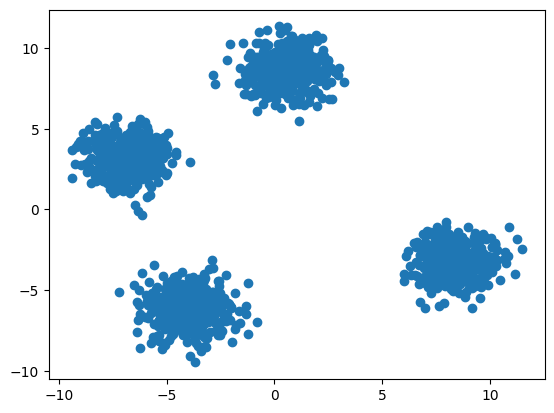

In [41]:
#generate data with K=4
X, y = make_blobs(n_samples=1500, centers=4)
plt.scatter(X[:, 0], X[:, 1])

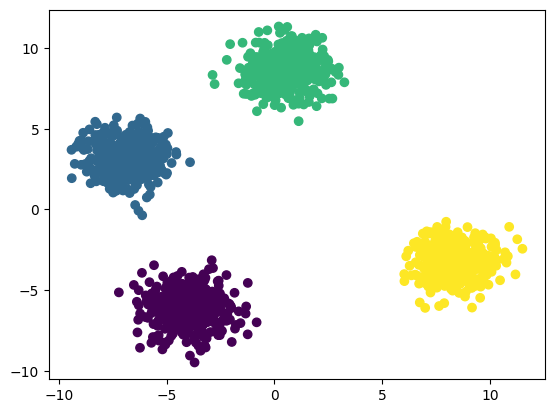

In [42]:
#K-Means ref implementation
k = KMeans(n_clusters=4, random_state=42)
y_pred = k.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred)

In [56]:
k.cluster_centers_
aktuelle_zenter= k.cluster_centers_
print(aktuelle_zenter)

[[-3.97645171 -6.16639317]
 [-6.82289761  3.19827486]
 [ 0.48371912  8.61472722]
 [ 8.3175117  -3.21649339]]


In [124]:
from functools import partial
from functools import reduce
#implement map -> assign data to center
def kMap(daten, centroiden):
    zentrum_l = 0

    for i, ks in enumerate(centroiden):
        aktuelle_distanz = abs(daten[0] - ks[0]) + abs(daten[1] - ks[1])
        beste_distanz = abs(daten[0] - centroiden[zentrum_l][0]) + abs(daten[1] - centroiden[zentrum_l][1])

        if aktuelle_distanz <= beste_distanz:
            zentrum_l = i

    return [(zentrum_l, daten)]


#print(X)
yepv= list(map(partial(kMap,centroiden=aktuelle_zenter),X))
yepv

[[(1, array([-5.93831214,  3.52294861]))],
 [(2, array([2.06937277, 7.93255022]))],
 [(0, array([-4.50891742, -5.98139882]))],
 [(1, array([-5.91964015,  0.73890627]))],
 [(1, array([-6.45846977,  3.50493604]))],
 [(0, array([-4.32219874, -5.7929036 ]))],
 [(3, array([ 9.6311686 , -2.81344075]))],
 [(3, array([ 8.3043143 , -3.67185876]))],
 [(1, array([-5.33904986,  3.74413202]))],
 [(3, array([10.06938067, -3.86692476]))],
 [(0, array([-3.47640387, -4.62037583]))],
 [(2, array([-0.61886223,  9.15962027]))],
 [(2, array([1.32403225, 9.66980966]))],
 [(1, array([-7.52024052,  3.84404119]))],
 [(0, array([-7.21528876, -5.14166206]))],
 [(0, array([-1.85104451, -5.16711881]))],
 [(3, array([ 8.77658829, -2.81065185]))],
 [(3, array([ 9.37236242, -1.63042311]))],
 [(2, array([-0.89835054,  7.10131413]))],
 [(1, array([-6.9280781 ,  3.80558472]))],
 [(0, array([-4.65102399, -5.71001174]))],
 [(3, array([ 7.77362656, -2.59438921]))],
 [(3, array([ 7.51064869, -3.89644081]))],
 [(1, array([-6

In [128]:
#implement reduce -> compute new centers
import functools
from collections import defaultdict
import numpy as np

def kReduce(item):
    centroid_id, data_points = item
    return (centroid_id, np.mean(data_points, axis=0))


In [129]:
#init centers
center = X[np.random.randint(X.shape[0], size=4), :]#get 4 random datapoints
print('init center', center)

init center [[ 1.70246773 10.40563213]
 [-5.33621977  3.17896744]
 [-3.49363238 -4.31830664]
 [ 7.96347299 -0.76475368]]


In [130]:
#use framework
mapper = SimpleMapReduce(partial(kMap,centroiden=aktuelle_zenter), kReduce)#get mapreduce instance with custom map and reduce functions
print(mapper)
center = mapper(X)#call parallel mapreduce oo data